In [68]:
import matplotlib.pyplot as plt
import numpy as np
import random
import math
from scipy.stats import beta

**Jennifer Kelley** - January 23, 2026

# Week 4 Assignment
*Chapter 5 Excercises (Sec 5.9)*

## Story 1 - Confidence Interval of Population Proportion: Preference between online classes and in-person classes
Suppose you survey 500 students, and 350 of them say they prefer online classes over in-person classes.
You want to calculate the 90% confidence interval for the true proportion of students who prefer online
classes.

#### Calculate the confidence interval using Python

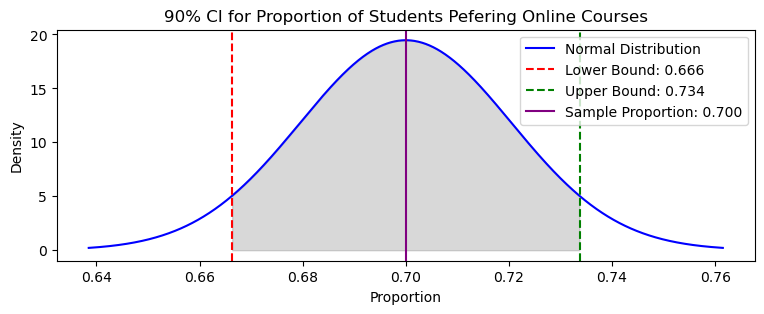

In [42]:
n = 500
p_hat = 350 / n
z_star = 1.645

se = np.sqrt((p_hat * (1 - p_hat)) / n)

margin_of_error = z_star * se
ci_lower = p_hat - margin_of_error
ci_upper = p_hat + margin_of_error

x = np.linspace(p_hat - 3*se, p_hat + 3*se, 1000)
y = norm.pdf(x, p_hat, se)

plt.figure(figsize=(9, 3))
plt.plot(x, y, label='Normal Distribution', color='blue')
plt.axvline(ci_lower, color='red', linestyle='--', label=f'Lower Bound: {ci_lower:.3f}')
plt.axvline(ci_upper, color='green', linestyle='--', label=f'Upper Bound: {ci_upper:.3f}')
plt.axvline(p_hat, color='purple', linestyle='-', label=f'Sample Proportion: {p_hat:.3f}')
plt.fill_between(x, y, where=(x >= ci_lower) & (x <= ci_upper), color='gray', alpha=0.3)

plt.title('90% CI for Proportion of Students Pefering Online Courses')
plt.xlabel('Proportion')
plt.ylabel('Density')
plt.legend()
plt.show()

#### Explain what the confidence interval means in context

Based on this sample, for this confidence interval (of 90%) `z_star = 1.645`,  we are 90% confident that between 66.6% and 73.4% of the student population prefer online classes over in-person classes.

##  Story 2 - Confidence Interval of Population Mean: Estimating the Average Daily Screen Time of Teenagers
Suppose a researcher wants to estimate the average daily screen time of teenagers. The researcher
collects a sample of 40 teenagers, finding a sample mean screen time of 4.5 hours with a sample standard
deviation of 1.2 hours. The researcher wishes to achieve a 95% confidence level.

#### Calculate the confidence interval using Python

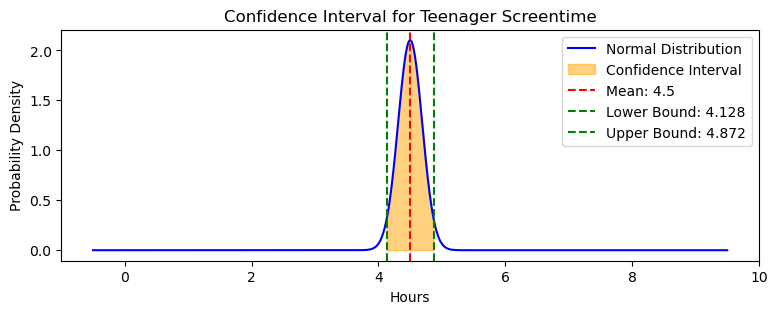

In [50]:
sample_mean = 4.5
sample_std = 1.2
sample_size = 40
confidence_level = .95

z_score = stats.norm.ppf((1 + confidence_level) / 2)

margin_of_error = z_score * (sample_std / np.sqrt(sample_size))

lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

x = np.linspace(sample_mean - 5, sample_mean + 5, 1000)
y = stats.norm.pdf(x, loc=sample_mean, scale=sample_std / np.sqrt(sample_size))

plt.figure(figsize=(9, 3))

plt.plot(x, y, label='Normal Distribution', color='blue')

plt.fill_between(x, y, where=((x >= lower_bound) & (x <= upper_bound)), interpolate=True, color='orange', alpha=0.5, label='Confidence Interval')

plt.axvline(sample_mean, color='red', linestyle='--', label=f'Mean: {sample_mean}')
plt.axvline(lower_bound, color='green', linestyle='--', label=f'Lower Bound: {lower_bound:.3f}')
plt.axvline(upper_bound, color='green', linestyle='--', label=f'Upper Bound: {upper_bound:.3f}')

plt.xlabel('Hours')
plt.ylabel('Probability Density')
plt.title('Confidence Interval for Teenager Screentime')
plt.legend()

plt.show()

#### Explain what the confidence interval means in context

For this confidence interval of 95% (`z_star` calculated to be `1.96`), we are 95% confident the average daily screen time for teenagers lies between ~4.13 and ~4.87 hours.

## Story 3 - Z-score: Workplace Skills Assessment
Suppose we have collected the raw scores of 50 employees on a workplace skills assessment. Assume
the raw scores follow a normal distribution.

#### Generate 50 random data points from a normal distribution with mean 70.0 and standard deviation 15.0

In [60]:
np.random.seed()
data = np.random.normal(loc=50, scale=15, size=40)

print("Generated data:", data.round(1))

Generated data: [ 29.9  63.   47.9  49.5  16.4  50.5  56.5  46.7  43.5  41.2  32.   61.
  36.4  40.   43.6  56.8  46.4  76.6  33.2  42.9  58.3  56.   56.5  54.7
  32.5  42.9  38.4  67.   62.9  60.3  44.3  48.9  54.6  63.   45.2  54.
  68.3 102.1  54.1  44.7]


#### Calculate the Z-score for each value

In [61]:
mean = np.mean(data)
std_dev = np.std(data, ddof=1)

z_scores = (data - mean) / std_dev

print("The Z-scores:", z_scores.round(1))

The Z-scores: [-1.4  0.9 -0.2 -0.1 -2.3 -0.   0.4 -0.3 -0.5 -0.6 -1.3  0.7 -1.  -0.7
 -0.5  0.4 -0.3  1.8 -1.2 -0.5  0.5  0.4  0.4  0.3 -1.2 -0.5 -0.8  1.1
  0.8  0.7 -0.4 -0.1  0.3  0.9 -0.4  0.2  1.2  3.5  0.2 -0.4]


#### Visualize the distribution & Annotate the Z-scores of the first 5 records

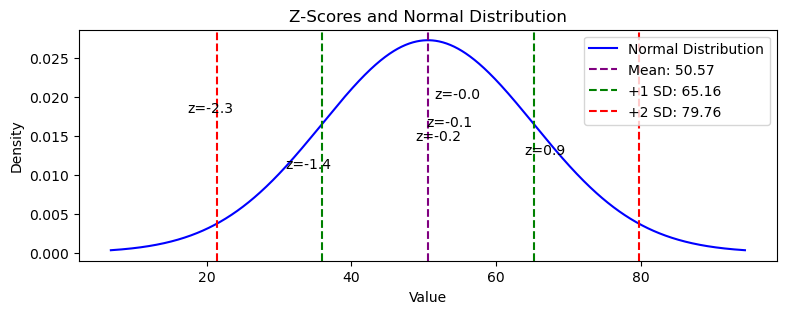

In [62]:
x_values = np.linspace(mean - 3*std_dev, mean + 3*std_dev, 1000)
y_values = norm.pdf(x_values, mean, std_dev)

plt.figure(figsize=(9, 3))
plt.plot(x_values, y_values, label='Normal Distribution', color='blue')
plt.axvline(mean, color='purple', linestyle='--', label=f'Mean: {mean:.2f}')
plt.axvline(mean + std_dev, color='green', linestyle='--', label=f'+1 SD: {mean + std_dev:.2f}')
plt.axvline(mean - std_dev, color='green', linestyle='--')
plt.axvline(mean + 2*std_dev, color='red', linestyle='--', label=f'+2 SD: {mean + 2*std_dev:.2f}')
plt.axvline(mean - 2*std_dev, color='red', linestyle='--')

for i in range(6):
    plt.annotate(f'z={z_scores[i]:.1f}', (data[i], 0.01), textcoords="offset points", xytext=(5,5+i*10))

plt.title('Z-Scores and Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

## Story 4 - T-score: Student’s Performance
Suppose we have collected the raw scores of 10 students.

#### Generate 10 random data points between 10 to 100

In [63]:
np.random.seed(42)
sample_scores = np.random.uniform(10, 100, size=10)

print("Generated data:", data.round(1))

Generated data: [ 29.9  63.   47.9  49.5  16.4  50.5  56.5  46.7  43.5  41.2  32.   61.
  36.4  40.   43.6  56.8  46.4  76.6  33.2  42.9  58.3  56.   56.5  54.7
  32.5  42.9  38.4  67.   62.9  60.3  44.3  48.9  54.6  63.   45.2  54.
  68.3 102.1  54.1  44.7]


#### Calculate the sample mean and sample standard deviation

In [64]:
sample_mean = np.mean(sample_scores)
sample_std_dev = np.std(sample_scores)

print("Sample Mean:", sample_mean)
print("Sample Standard Deviation:", sample_std_dev)

Sample Mean: 56.81230623574074
Sample Standard Deviation: 26.969079663084923


#### Calculate the T-score for each value

In [67]:
n = len(sample_scores)
t_scores = (sample_scores - sample_mean) / (sample_std_dev / np.sqrt(n))

print("T-Scores:", t_scores.round(2))

T-Scores: [-1.54  4.54  2.24  0.83 -3.84 -3.84 -4.88  3.65  0.85  1.98]


## Story 5 - Estimating the Average Age of Employees in a Corporation Using Stratified Sampling
A corporation wants to estimate the average age of its employees. The total number of employees in
the corporation is 50,000. The human resources department decides to use stratified sampling to ensure
that each age group is well-represented in the sample. The employee population is divided into different
age brackets (strata) as follows:
- Young employees (18-30 years): 20,000 employees
- Middle-aged employees (31-50 years): 20,000 employees
- Older employees (51+ years): 10,000 employees

The human resources department desires a confidence interval of 95%. From previous studies, they
know the standard deviations for the three age groups are:
- Young employees: $\sigma_Y$ = 5 years
- Middle-aged employees: $\sigma_M$ = 6 years
- Older employees: $\sigma_O$ = 7 years

The department wants the estimate of the average age to be within 1 year of the true mean.

#### Determine the minimum sample size

In [79]:
N_Y = 20000
N_M = 20000
N_O = 10000

sigma_Y = 5
sigma_M = 6
sigma_O = 7

Z = 1.96
E = 1

def calculate_sample_size(Z, sigma, E):
    return (Z**2 * sigma**2) / (E**2)

n_Y = calculate_sample_size(Z, sigma_Y, E)
n_Y = math.ceil(n_Y)
n_M = calculate_sample_size(Z, sigma_M, E)
n_M = math.ceil(n_M)
n_O = calculate_sample_size(Z, sigma_O, E)
n_O = math.ceil(n_O)
n_total = n_Y + n_M + n_O

print(f"Sample size for young employees: {n_Y}")
print(f"Sample size for middle-aged employees: {n_M}")
print(f"Sample size for older employees: {n_O}")
print(f"Total sample size: { n_total }")

Sample size for young employees: 97
Sample size for middle-aged employees: 139
Sample size for older employees: 189
Total sample size: 425


## Story 6 - Estimating the Proportion of Residents Who Own a Car in a City Using Stratified Sampling
A city wants to estimate the proportion of residents who own a car. The city’s total population is 100,000. The city department decides to use stratified sampling to ensure that different types of neighborhoods (with varying car ownership rates) are well-represented in the sample. The population is divided into three types of neighborhoods (strata) based on car ownership rates:
- Urban areas: 50,000 residents
- Suburban areas: 30,000 residents
- Rural areas: 20,000 residents

The city department desires the confidence interval to be 95%. From previous studies, the department estimates that:
-  In urban areas, the proportion of car owners is $p_U = 0.75$
-  In suburban areas, the proportion is $p_S = 0.60$
-  In rural areas, the proportion is $p_R = 0.40$

The department wants the estimate of the car ownership proportion to be within 0.03 of the true proportion.

####  Determine the minimum sample size required

In [83]:
N_U = 50000
N_S = 30000
N_R = 20000
N_total = N_U + N_S + N_R

P_U = .75
P_S = .60
P_R = .4

Z = 1.96
E = .03

def calculate_sample_size(Z, P, E):
    return ((Z**2 * P) * (1 - P)) / (E**2)

n_U = calculate_sample_size(Z, P_U, E)
n_U = math.ceil(n_U)
n_S = calculate_sample_size(Z, P_S, E)
n_S = math.ceil(n_S)
n_R = calculate_sample_size(Z, P_R, E)
n_R = math.ceil(n_R)
n_total = n_U + n_S + n_R

prop_U = (N_U / N_total) * n_U
prop_S = (N_S / N_total) * n_S
prop_R = (N_R / N_total) * n_R

print(f"Proportion of car ownership in Urban areas: {prop_U}")
print(f"Proportion of car ownership in Suburban areas: {prop_S}")
print(f"Proportion of car ownership in Rural areas: {prop_R}")
print(f"Total proportion: { prop_U + prop_S + prop_R }")

Proportion of car ownership in Urban areas: 400.5
Proportion of car ownership in Suburban areas: 307.5
Proportion of car ownership in Rural areas: 205.0
Total proportion: 913.0
